# 🎯 Analyse des Attributs Discriminants pour la Prédiction du Score de Mathématiques

## HI!CKATHON 2025 - HEC Paris & Institut Polytechnique de Paris

---

**Objectif**: Identifier les variables les plus importantes pour prédire le score de mathématiques (Math Score) des élèves PISA à travers:

1. 📊 **Analyse de corrélation** - Matrice de corrélation avec la variable cible
2. 📈 **Visualisations avancées** - Distribution des features vs Math Score
3. 🔍 **Feature Importance** - Importance des variables via Random Forest
4. 🎨 **Analyse bivariée** - Relations entre features et target
5. 🧮 **Feature Selection** - Sélection des meilleures variables pour le ML

**Variable Cible**: Score de Mathématiques (PV1MATH, PV2MATH, PV3MATH...)

## 1️⃣ Import des Bibliothèques

In [5]:
# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Statistics
from scipy.stats import pearsonr, spearmanr
from scipy.cluster import hierarchy

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


## 2️⃣ Chargement des Données

In [6]:
# Chargement des données
print("📂 Chargement des données...")
X_train = pd.read_csv('X_train.csv', low_memory=False)
y_train = pd.read_csv('y_train.csv', low_memory=False)

print(f"✅ X_train: {X_train.shape}")
print(f"✅ y_train: {y_train.shape}")

# Identifier la colonne du score de mathématiques
math_score_cols = [col for col in y_train.columns if 'MATH' in col.upper() or 'PV' in col]
print(f"\n🎯 Colonnes de score de maths trouvées: {math_score_cols}")

# Utiliser la première colonne de score de maths (moyenne si plusieurs)
if len(math_score_cols) > 0:
    if len(math_score_cols) == 1:
        target_col = math_score_cols[0]
    else:
        # Si plusieurs colonnes PV (Plausible Values), calculer la moyenne
        y_train['MATH_SCORE_AVG'] = y_train[math_score_cols].mean(axis=1)
        target_col = 'MATH_SCORE_AVG'
        print(f"📊 Moyenne calculée sur {len(math_score_cols)} Plausible Values")
    
    print(f"\n🎯 Variable cible sélectionnée: {target_col}")
    
    # Statistiques de la variable cible
    print(f"\n📈 Statistiques du Math Score:")
    print(y_train[target_col].describe())
else:
    print("⚠️ Aucune colonne de score de maths trouvée!")
    target_col = y_train.columns[0]  # Fallback

📂 Chargement des données...
✅ X_train: (1172086, 307)
✅ y_train: (1172086, 2)

🎯 Colonnes de score de maths trouvées: ['MathScore']

🎯 Variable cible sélectionnée: MathScore

📈 Statistiques du Math Score:
count    1.172086e+06
mean     9.999513e+01
std      1.221761e+02
min      0.000000e+00
25%      0.000000e+00
50%      6.604880e+01
75%      1.528073e+02
max      8.149725e+02
Name: MathScore, dtype: float64
✅ X_train: (1172086, 307)
✅ y_train: (1172086, 2)

🎯 Colonnes de score de maths trouvées: ['MathScore']

🎯 Variable cible sélectionnée: MathScore

📈 Statistiques du Math Score:
count    1.172086e+06
mean     9.999513e+01
std      1.221761e+02
min      0.000000e+00
25%      0.000000e+00
50%      6.604880e+01
75%      1.528073e+02
max      8.149725e+02
Name: MathScore, dtype: float64


## 3️⃣ Preprocessing et Nettoyage Initial

In [7]:
# Remplacer les codes manquants PISA par NaN
print("🔧 Nettoyage des codes manquants PISA...")
missing_codes = [9999, 999, 99, 99999]
X_train_clean = X_train.replace(missing_codes, np.nan)

# Supprimer les colonnes avec >80% de valeurs manquantes
threshold = 0.8
null_pct = X_train_clean.isnull().mean()
cols_to_keep = null_pct[null_pct < threshold].index.tolist()
X_train_clean = X_train_clean[cols_to_keep]

print(f"✅ Colonnes conservées: {len(cols_to_keep)} / {len(X_train.columns)}")
print(f"🗑️ Colonnes supprimées: {len(X_train.columns) - len(cols_to_keep)}")

# Garder uniquement les colonnes numériques pour l'analyse de corrélation
numeric_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
X_numeric = X_train_clean[numeric_cols].copy()

print(f"\n📊 Variables numériques pour l'analyse: {len(numeric_cols)}")

# Créer un dataset complet (X + y) pour l'analyse
df_analysis = X_numeric.copy()
df_analysis[target_col] = y_train[target_col].values

# Supprimer les lignes où le target est manquant
df_analysis = df_analysis.dropna(subset=[target_col])
print(f"\n✅ Dataset pour l'analyse: {df_analysis.shape}")

🔧 Nettoyage des codes manquants PISA...
✅ Colonnes conservées: 256 / 307
🗑️ Colonnes supprimées: 51
✅ Colonnes conservées: 256 / 307
🗑️ Colonnes supprimées: 51

📊 Variables numériques pour l'analyse: 253

📊 Variables numériques pour l'analyse: 253

✅ Dataset pour l'analyse: (1172086, 254)

✅ Dataset pour l'analyse: (1172086, 254)


## 4️⃣ Analyse de Corrélation avec le Math Score

In [8]:
# Calculer la corrélation de chaque variable avec le Math Score
print("📊 Calcul des corrélations avec le Math Score...")

correlations = []
for col in df_analysis.columns:
    if col != target_col:
        # Calculer la corrélation uniquement sur les valeurs non-nulles
        valid_data = df_analysis[[col, target_col]].dropna()
        
        if len(valid_data) > 100:  # Au moins 100 observations valides
            corr_pearson, _ = pearsonr(valid_data[col], valid_data[target_col])
            correlations.append({
                'Feature': col,
                'Correlation': corr_pearson,
                'Abs_Correlation': abs(corr_pearson),
                'Valid_Samples': len(valid_data)
            })

# Créer un DataFrame des corrélations
corr_df = pd.DataFrame(correlations).sort_values('Abs_Correlation', ascending=False)

print(f"✅ Corrélations calculées pour {len(corr_df)} variables")
print(f"\n🔝 Top 20 Variables les Plus Corrélées avec le Math Score:")
display(corr_df.head(20))

📊 Calcul des corrélations avec le Math Score...
✅ Corrélations calculées pour 253 variables

🔝 Top 20 Variables les Plus Corrélées avec le Math Score:
✅ Corrélations calculées pour 253 variables

🔝 Top 20 Variables les Plus Corrélées avec le Math Score:


,Feature,Correlation,Abs_Correlation,Valid_Samples
202,math_q2_average_score,0.438035,0.438035,733844
203,math_q3_average_score,0.420541,0.420541,730610
212,math_q12_average_score,0.413307,0.413307,303643
211,math_q11_average_score,0.396575,0.396575,442752
207,math_q7_average_score,0.384159,0.384159,664170
201,math_q1_average_score,0.375285,0.375285,735735
209,math_q9_average_score,0.356616,0.356616,606061
208,math_q8_average_score,0.351035,0.351035,633849
210,math_q10_average_score,0.348139,0.348139,530955
206,math_q6_average_score,0.335085,0.335085,681869


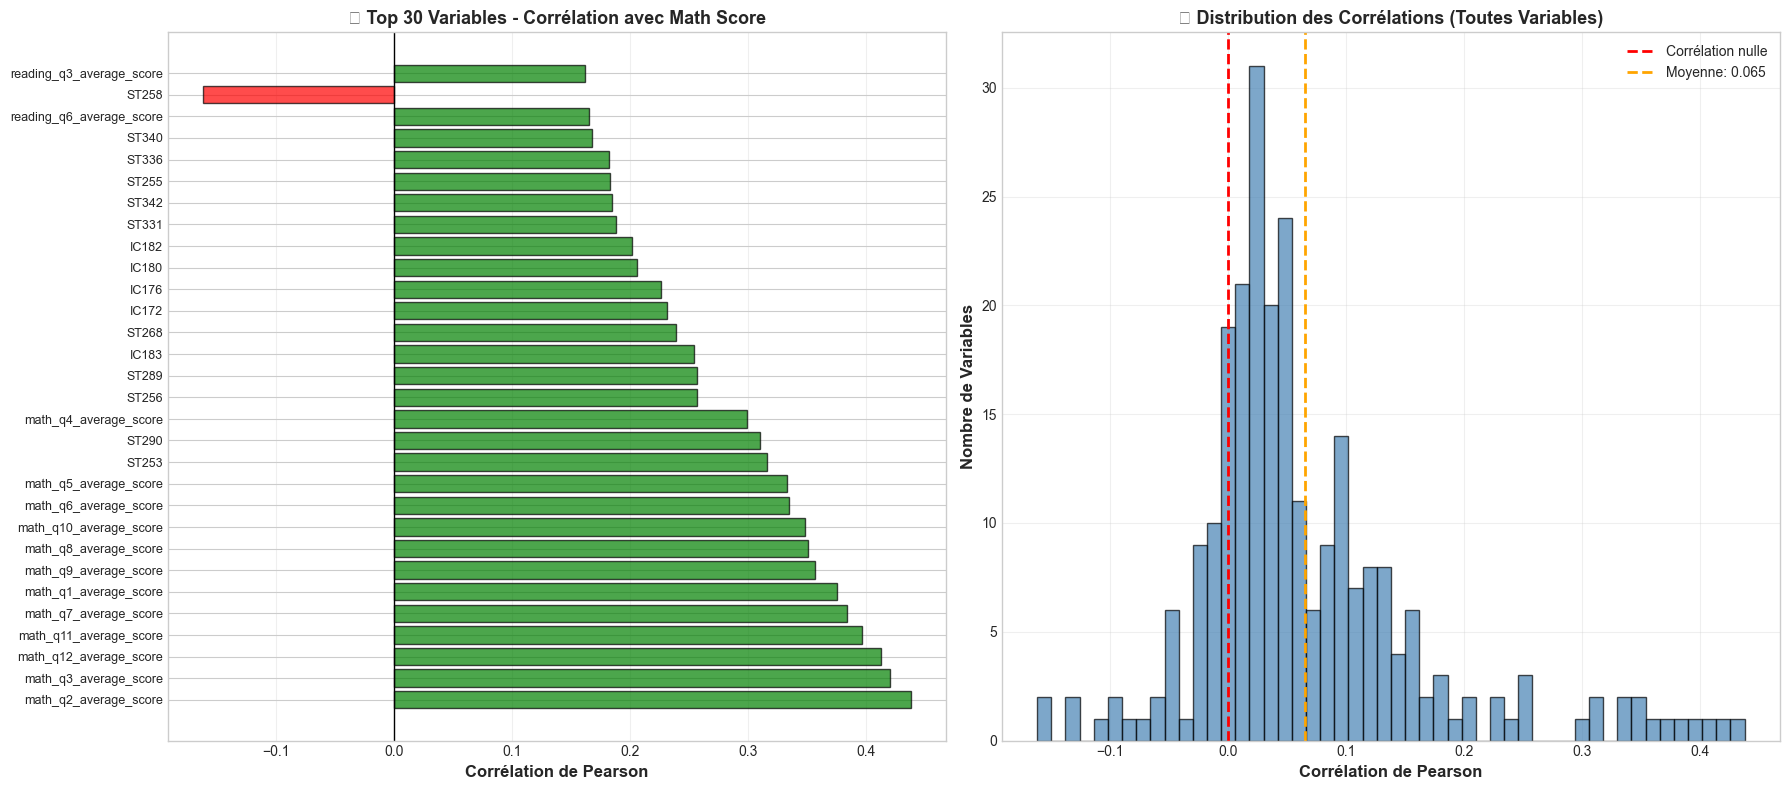


📈 Statistiques des corrélations:
  • Corrélation maximale: 0.4380
  • Corrélation moyenne: 0.0799
  • Variables avec |r| > 0.5: 0
  • Variables avec |r| > 0.3: 13
  • Variables avec |r| > 0.1: 68


In [9]:
# Visualisation 1: Barplot des Top 30 Corrélations
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 30 corrélations positives et négatives
top_corr = corr_df.head(30)

# Barplot horizontal
colors = ['green' if x > 0 else 'red' for x in top_corr['Correlation']]
axes[0].barh(range(len(top_corr)), top_corr['Correlation'], color=colors, alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr['Feature'], fontsize=9)
axes[0].set_xlabel('Corrélation de Pearson', fontsize=12, fontweight='bold')
axes[0].set_title('🔝 Top 30 Variables - Corrélation avec Math Score', fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].grid(axis='x', alpha=0.3)

# Distribution des corrélations (toutes variables)
axes[1].hist(corr_df['Correlation'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Corrélation nulle')
axes[1].axvline(x=corr_df['Correlation'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Moyenne: {corr_df["Correlation"].mean():.3f}')
axes[1].set_xlabel('Corrélation de Pearson', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre de Variables', fontsize=12, fontweight='bold')
axes[1].set_title('📊 Distribution des Corrélations (Toutes Variables)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques
print(f"\n📈 Statistiques des corrélations:")
print(f"  • Corrélation maximale: {corr_df['Abs_Correlation'].max():.4f}")
print(f"  • Corrélation moyenne: {corr_df['Abs_Correlation'].mean():.4f}")
print(f"  • Variables avec |r| > 0.5: {(corr_df['Abs_Correlation'] > 0.5).sum()}")
print(f"  • Variables avec |r| > 0.3: {(corr_df['Abs_Correlation'] > 0.3).sum()}")
print(f"  • Variables avec |r| > 0.1: {(corr_df['Abs_Correlation'] > 0.1).sum()}")

## 5️⃣ Matrice de Corrélation Interactive (Top Features)

📊 Calcul de la matrice de corrélation pour les top 20 features...
   Dataset: (164286, 21)


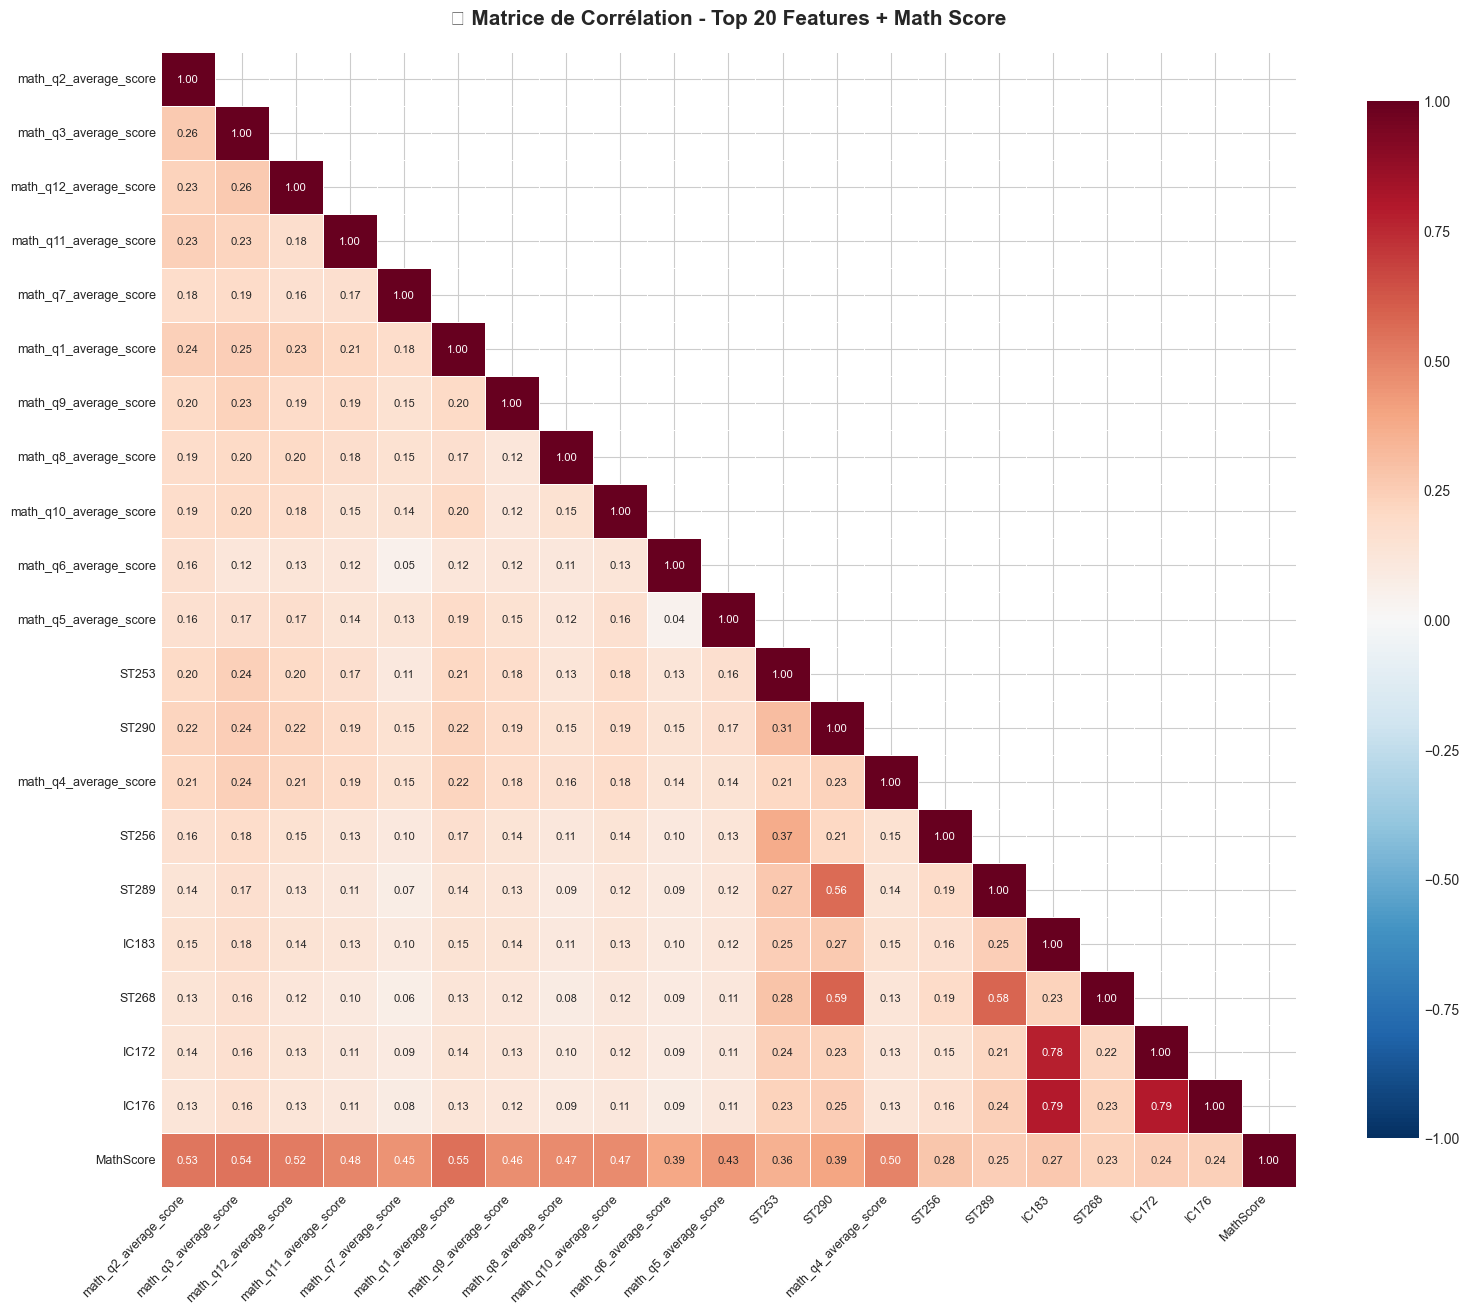


⚠️ Paires de features fortement corrélées (|r| > 0.8) - Risque de multicolinéarité:
✅ Aucune corrélation excessive détectée entre features


In [10]:
# Sélectionner les top 20 features + target
top_features = corr_df.head(20)['Feature'].tolist()
top_features.append(target_col)

# Sous-ensemble du dataframe
df_top = df_analysis[top_features].dropna()

print(f"📊 Calcul de la matrice de corrélation pour les top 20 features...")
print(f"   Dataset: {df_top.shape}")

# Matrice de corrélation
corr_matrix = df_top.corr()

# Heatmap avec Seaborn
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('🔥 Matrice de Corrélation - Top 20 Features + Math Score', 
          fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Identifier les paires hautement corrélées (potentiel problème de multicolinéarité)
print("\n⚠️ Paires de features fortement corrélées (|r| > 0.8) - Risque de multicolinéarité:")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j].round(3)
            })

if len(high_corr_pairs) > 0:
    display(pd.DataFrame(high_corr_pairs))
else:
    print("✅ Aucune corrélation excessive détectée entre features")

## 6️⃣ Feature Importance avec Random Forest

In [11]:
# Préparer les données pour Random Forest
print("🌲 Entraînement d'un Random Forest pour calculer l'importance des features...")

# Prendre un échantillon si le dataset est trop grand (pour la performance)
sample_size = min(50000, len(df_analysis))
df_sample = df_analysis.sample(n=sample_size, random_state=42)

# Séparer X et y
X = df_sample.drop(columns=[target_col])
y = df_sample[target_col]

# Imputer les valeurs manquantes
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"   Dataset: {X_imputed.shape}")
print(f"   Entraînement en cours...")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_imputed, y)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"✅ Random Forest entraîné!")
print(f"\n🔝 Top 20 Features par Importance (Random Forest):")
display(feature_importance.head(20))

🌲 Entraînement d'un Random Forest pour calculer l'importance des features...
   Dataset: (50000, 253)
   Entraînement en cours...
   Dataset: (50000, 253)
   Entraînement en cours...
✅ Random Forest entraîné!

🔝 Top 20 Features par Importance (Random Forest):
✅ Random Forest entraîné!

🔝 Top 20 Features par Importance (Random Forest):


,Feature,Importance
203,math_q3_average_score,0.210480
201,math_q1_average_score,0.189626
202,math_q2_average_score,0.134395
0,Unnamed: 0,0.099989
209,math_q9_average_score,0.093901
212,math_q12_average_score,0.077433
211,math_q11_average_score,0.032763
208,math_q8_average_score,0.032176
207,math_q7_average_score,0.028490
204,math_q4_average_score,0.018382


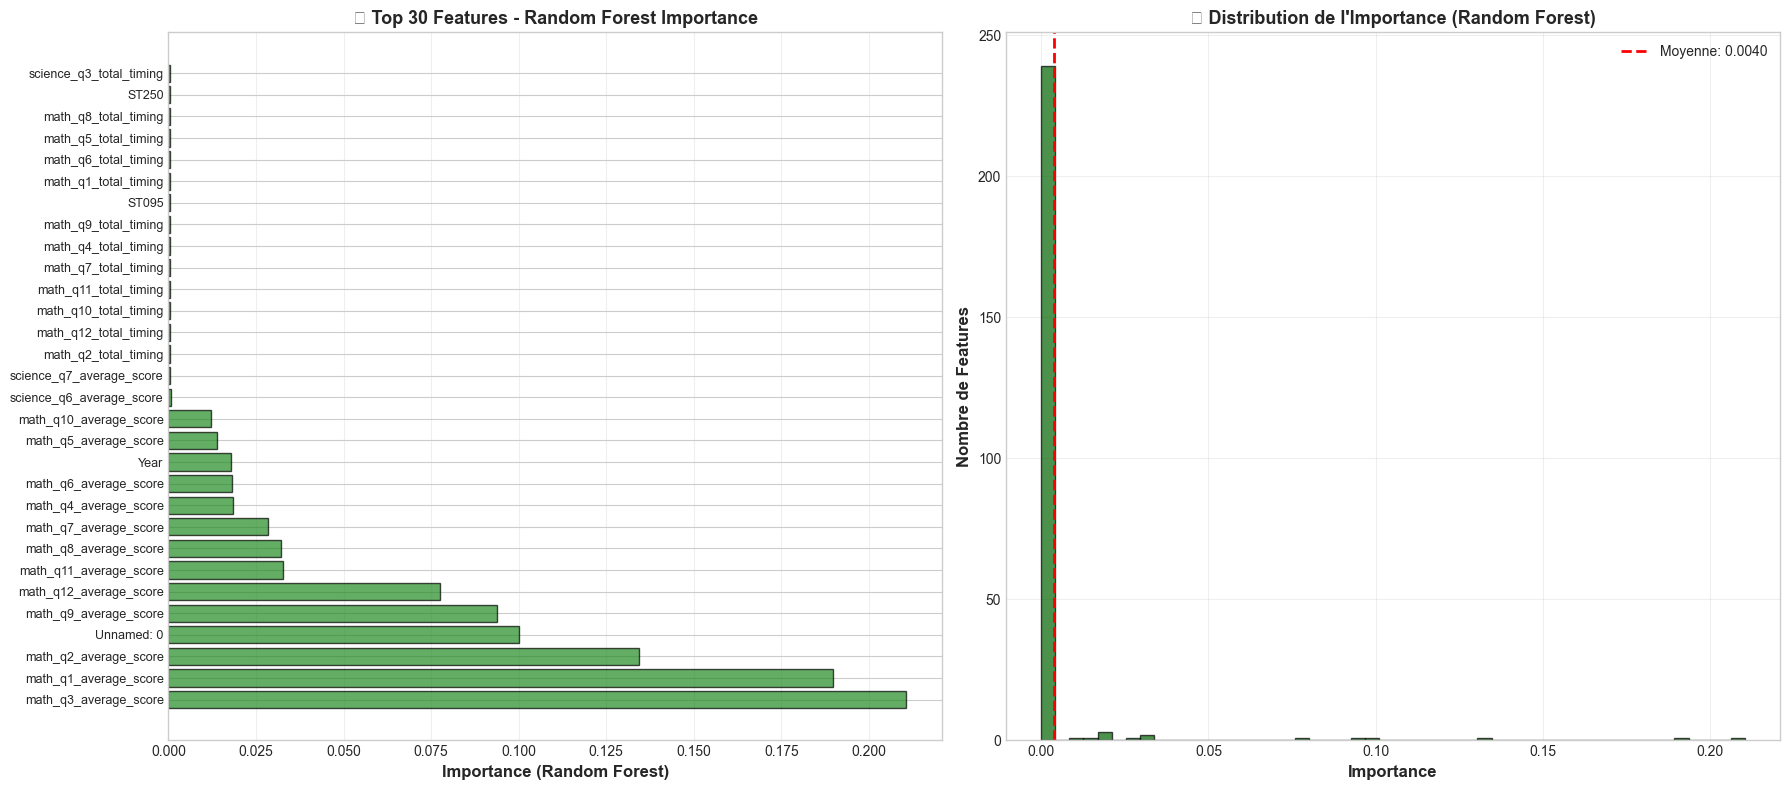


📊 9 features expliquent 90% de l'importance totale


In [12]:
# Visualisation Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 30 Features
top_30_importance = feature_importance.head(30)

axes[0].barh(range(len(top_30_importance)), top_30_importance['Importance'], 
             color='forestgreen', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_30_importance)))
axes[0].set_yticklabels(top_30_importance['Feature'], fontsize=9)
axes[0].set_xlabel('Importance (Random Forest)', fontsize=12, fontweight='bold')
axes[0].set_title('🌲 Top 30 Features - Random Forest Importance', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Distribution de l'importance
axes[1].hist(feature_importance['Importance'], bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
axes[1].axvline(x=feature_importance['Importance'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne: {feature_importance["Importance"].mean():.4f}')
axes[1].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre de Features', fontsize=12, fontweight='bold')
axes[1].set_title('📊 Distribution de l\'Importance (Random Forest)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Importance cumulative
cumsum = feature_importance['Importance'].cumsum()
n_features_90 = (cumsum <= 0.90).sum()
print(f"\n📊 {n_features_90} features expliquent 90% de l'importance totale")

## 7️⃣ Analyse Bivariée - Scatter Plots (Top Features)

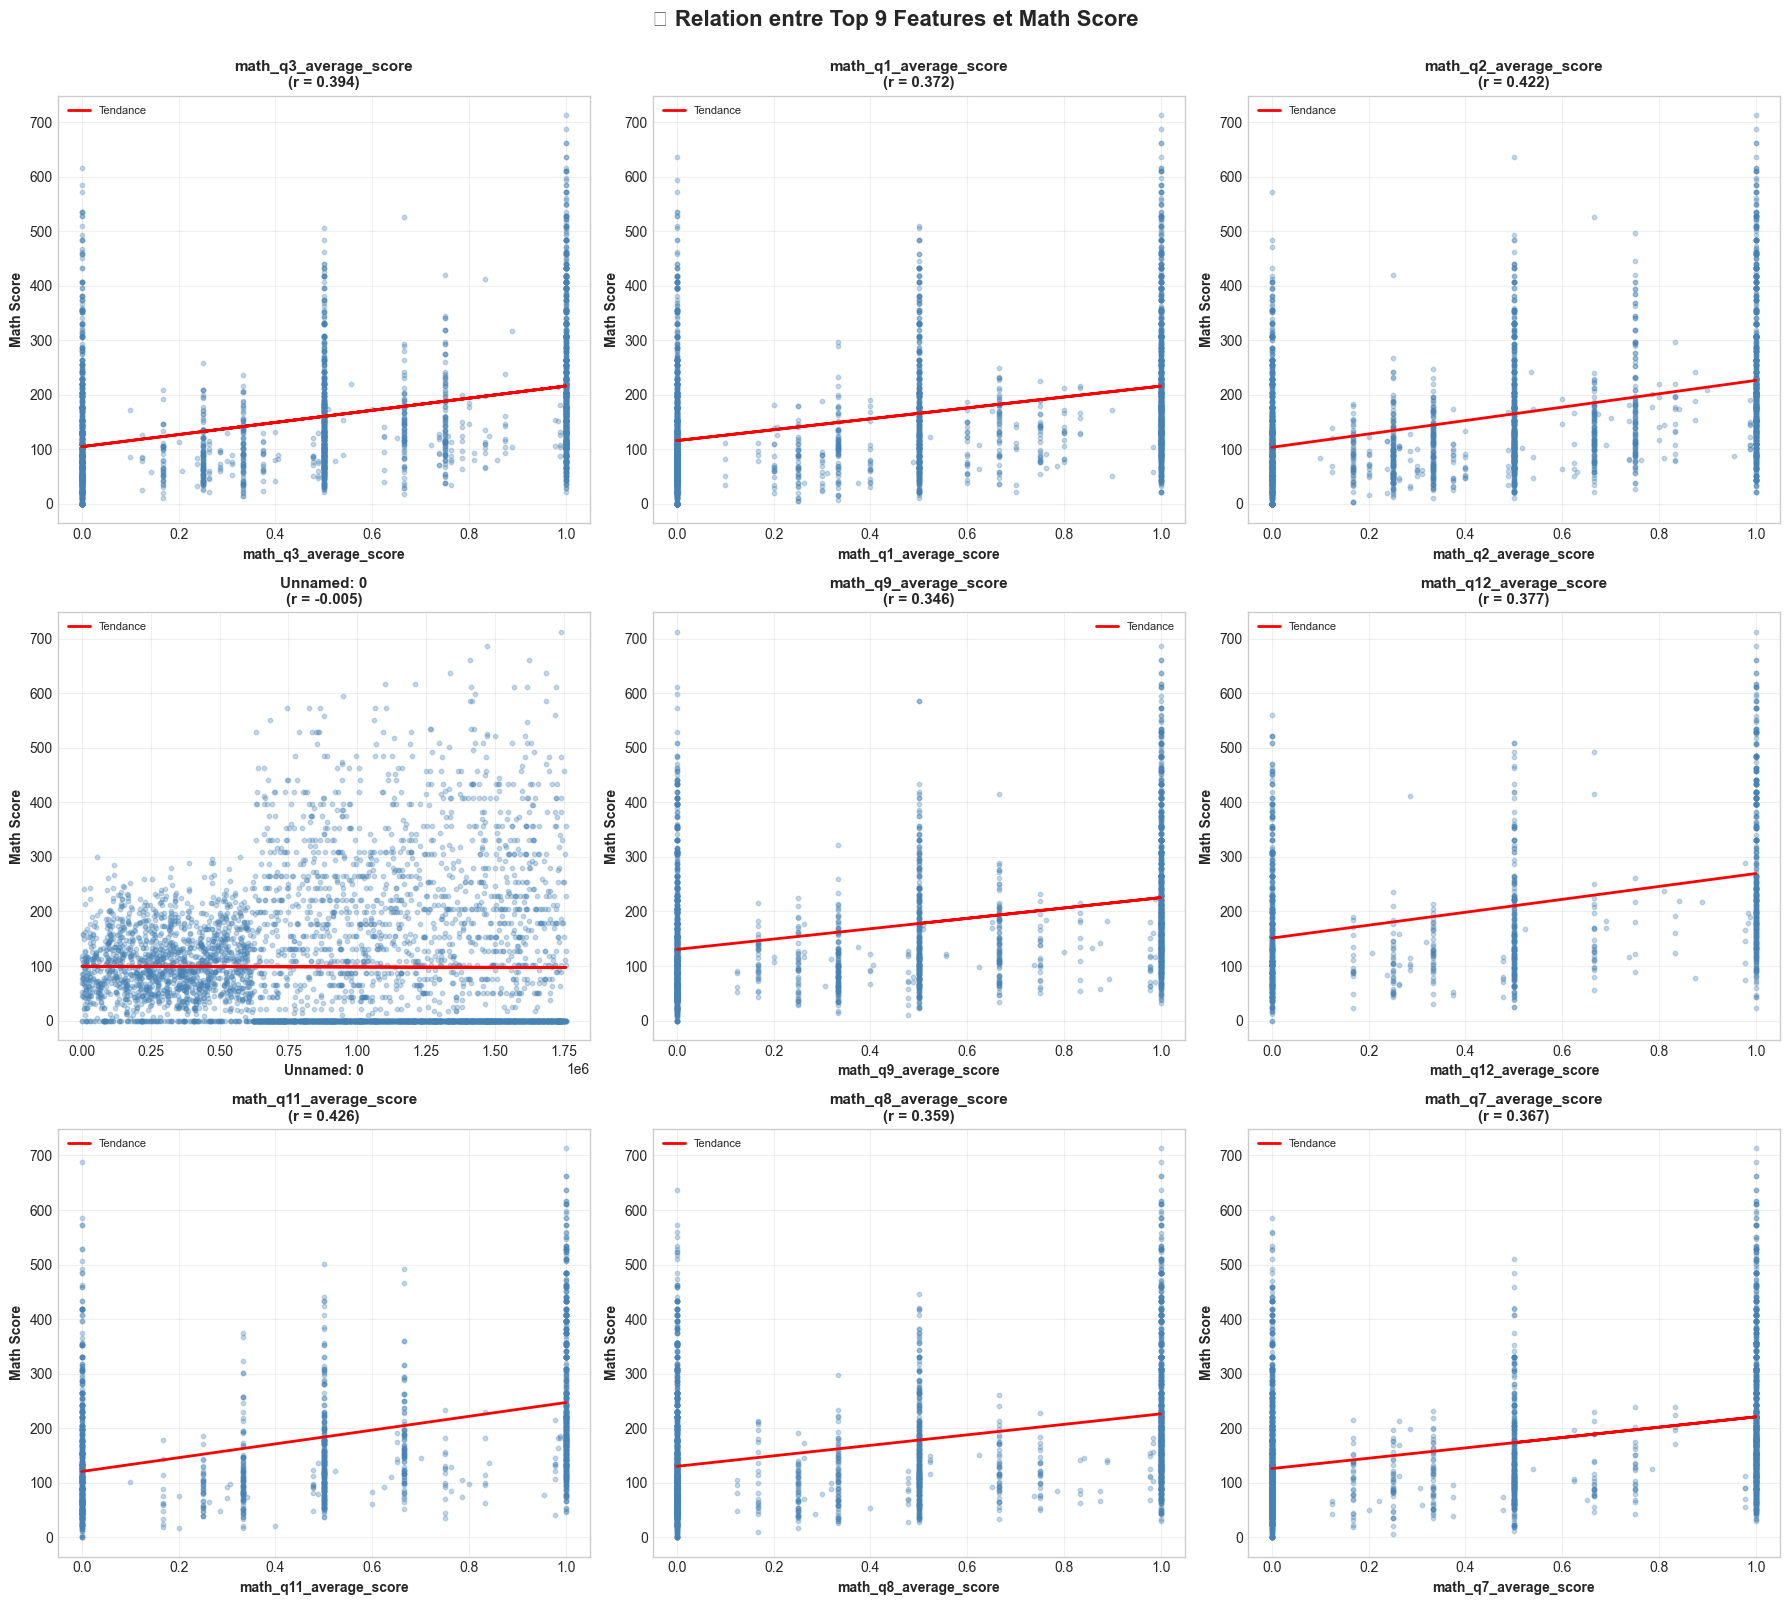

In [13]:
# Scatter plots pour les 9 features les plus importantes
top_9_features = feature_importance.head(9)['Feature'].tolist()

# Échantillon pour la visualisation
plot_sample = df_analysis.sample(n=min(5000, len(df_analysis)), random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, feature in enumerate(top_9_features):
    if idx < len(axes):
        # Données valides
        valid_data = plot_sample[[feature, target_col]].dropna()
        
        if len(valid_data) > 0:
            # Scatter plot avec ligne de tendance
            axes[idx].scatter(valid_data[feature], valid_data[target_col], 
                            alpha=0.3, s=10, color='steelblue')
            
            # Ligne de tendance
            z = np.polyfit(valid_data[feature], valid_data[target_col], 1)
            p = np.poly1d(z)
            axes[idx].plot(valid_data[feature], p(valid_data[feature]), 
                          "r-", linewidth=2, label='Tendance')
            
            # Corrélation
            corr = valid_data[feature].corr(valid_data[target_col])
            
            axes[idx].set_xlabel(feature, fontsize=10, fontweight='bold')
            axes[idx].set_ylabel('Math Score', fontsize=10, fontweight='bold')
            axes[idx].set_title(f'{feature}\n(r = {corr:.3f})', fontsize=11, fontweight='bold')
            axes[idx].grid(alpha=0.3)
            axes[idx].legend(fontsize=8)

plt.suptitle('📊 Relation entre Top 9 Features et Math Score', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8️⃣ Comparaison des Méthodes de Feature Selection

In [14]:
# Comparer différentes méthodes de sélection de features
print("🔍 Comparaison de 3 méthodes de Feature Selection...")

# 1. Corrélation (déjà calculée)
top_20_corr = set(corr_df.head(20)['Feature'].tolist())

# 2. Random Forest Importance
top_20_rf = set(feature_importance.head(20)['Feature'].tolist())

# 3. Mutual Information
print("   Calcul de la Mutual Information...")
selector = SelectKBest(score_func=mutual_info_regression, k=20)
selector.fit(X_imputed, y)
mi_scores = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': selector.scores_
}).sort_values('MI_Score', ascending=False)
top_20_mi = set(mi_scores.head(20)['Feature'].tolist())

print("✅ Calculs terminés!")

# Créer un DataFrame de comparaison
comparison_df = pd.DataFrame({
    'Rank': range(1, 21),
    'Correlation': corr_df.head(20)['Feature'].tolist(),
    'Random_Forest': feature_importance.head(20)['Feature'].tolist(),
    'Mutual_Info': mi_scores.head(20)['Feature'].tolist()
})

print("\n📊 Comparaison des Top 20 Features par méthode:")
display(comparison_df)

# Trouver les features communes aux 3 méthodes
common_all_3 = top_20_corr & top_20_rf & top_20_mi
common_2_methods = (top_20_corr & top_20_rf) | (top_20_corr & top_20_mi) | (top_20_rf & top_20_mi)

print(f"\n🎯 Features apparaissant dans les 3 méthodes: {len(common_all_3)}")
if len(common_all_3) > 0:
    print(f"   {sorted(list(common_all_3))}")

print(f"\n✅ Features apparaissant dans au moins 2 méthodes: {len(common_2_methods)}")
if len(common_2_methods) > 0:
    print(f"   {sorted(list(common_2_methods))}")

🔍 Comparaison de 3 méthodes de Feature Selection...
   Calcul de la Mutual Information...
✅ Calculs terminés!

📊 Comparaison des Top 20 Features par méthode:
✅ Calculs terminés!

📊 Comparaison des Top 20 Features par méthode:


,Rank,Correlation,Random_Forest,Mutual_Info
0,1,math_q2_average_score,math_q3_average_score,math_q1_average_score
1,2,math_q3_average_score,math_q1_average_score,Year
2,3,math_q12_average_score,math_q2_average_score,ST003D03T
3,4,math_q11_average_score,Unnamed: 0,math_q5_average_score
4,5,math_q7_average_score,math_q9_average_score,math_q9_average_score
5,6,math_q1_average_score,math_q12_average_score,math_q7_average_score
6,7,math_q9_average_score,math_q11_average_score,math_q8_average_score
7,8,math_q8_average_score,math_q8_average_score,math_q2_average_score
8,9,math_q10_average_score,math_q7_average_score,math_q3_average_score
9,10,math_q6_average_score,math_q4_average_score,ST255



🎯 Features apparaissant dans les 3 méthodes: 8
   ['math_q1_average_score', 'math_q2_average_score', 'math_q3_average_score', 'math_q4_average_score', 'math_q5_average_score', 'math_q7_average_score', 'math_q8_average_score', 'math_q9_average_score']

✅ Features apparaissant dans au moins 2 méthodes: 15
   ['Unnamed: 0', 'Year', 'math_q10_average_score', 'math_q11_average_score', 'math_q12_average_score', 'math_q1_average_score', 'math_q2_average_score', 'math_q2_total_timing', 'math_q3_average_score', 'math_q4_average_score', 'math_q5_average_score', 'math_q6_average_score', 'math_q7_average_score', 'math_q8_average_score', 'math_q9_average_score']


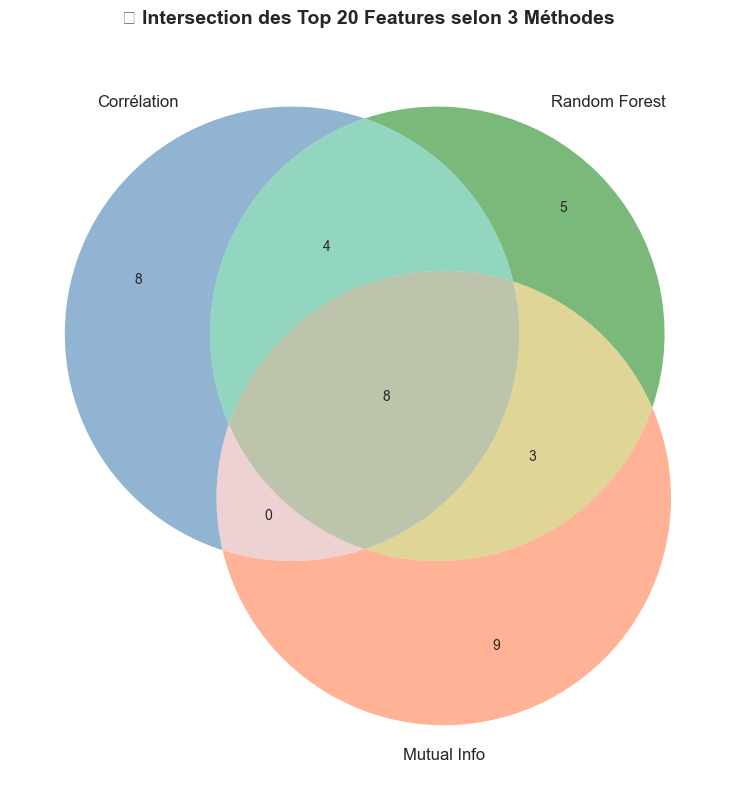

In [15]:
# Venn Diagram des intersections
from matplotlib_venn import venn3

plt.figure(figsize=(10, 8))
venn3([top_20_corr, top_20_rf, top_20_mi], 
      set_labels=('Corrélation', 'Random Forest', 'Mutual Info'),
      set_colors=('steelblue', 'forestgreen', 'coral'),
      alpha=0.6)
plt.title('🔄 Intersection des Top 20 Features selon 3 Méthodes', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 9️⃣ Feature Selection Finale - Recommandations pour le ML

In [16]:
# Créer un score composite pour chaque feature
print("🎯 Création d'un score composite de sélection...")

# Normaliser les scores de chaque méthode (0-1)
corr_df['Corr_Score'] = (corr_df['Abs_Correlation'] / corr_df['Abs_Correlation'].max())
feature_importance['RF_Score'] = (feature_importance['Importance'] / feature_importance['Importance'].max())
mi_scores['MI_Score_Norm'] = (mi_scores['MI_Score'] / mi_scores['MI_Score'].max())

# Merger tous les scores
final_scores = corr_df[['Feature', 'Corr_Score', 'Abs_Correlation']].copy()
final_scores = final_scores.merge(
    feature_importance[['Feature', 'RF_Score', 'Importance']], 
    on='Feature', how='outer'
)
final_scores = final_scores.merge(
    mi_scores[['Feature', 'MI_Score_Norm', 'MI_Score']], 
    on='Feature', how='outer'
)

# Remplir les NaN par 0
final_scores = final_scores.fillna(0)

# Score composite (moyenne des 3 méthodes)
final_scores['Composite_Score'] = (
    final_scores['Corr_Score'] + 
    final_scores['RF_Score'] + 
    final_scores['MI_Score_Norm']
) / 3

# Trier par score composite
final_scores = final_scores.sort_values('Composite_Score', ascending=False)

print("✅ Scores composites calculés!")
print(f"\n🏆 Top 30 Features - Score Composite (Recommandé pour le ML):")
display(final_scores.head(30)[['Feature', 'Composite_Score', 'Abs_Correlation', 'Importance', 'MI_Score']])

🎯 Création d'un score composite de sélection...
✅ Scores composites calculés!

🏆 Top 30 Features - Score Composite (Recommandé pour le ML):


,Feature,Composite_Score,Abs_Correlation,Importance,MI_Score
199,math_q1_average_score,0.919224,0.375285,0.189626,0.763618
203,math_q3_average_score,0.897125,0.420541,0.210480,0.558445
201,math_q2_average_score,0.796655,0.438035,0.134395,0.573820
215,math_q9_average_score,0.686980,0.356616,0.093901,0.611417
211,math_q7_average_score,0.602214,0.384159,0.028490,0.606527
213,math_q8_average_score,0.571643,0.351035,0.032176,0.580864
207,math_q5_average_score,0.562604,0.333287,0.013840,0.657618
197,math_q12_average_score,0.534838,0.413307,0.077433,0.223799
195,math_q11_average_score,0.513090,0.396575,0.032763,0.365208
205,math_q4_average_score,0.474409,0.299758,0.018382,0.497548


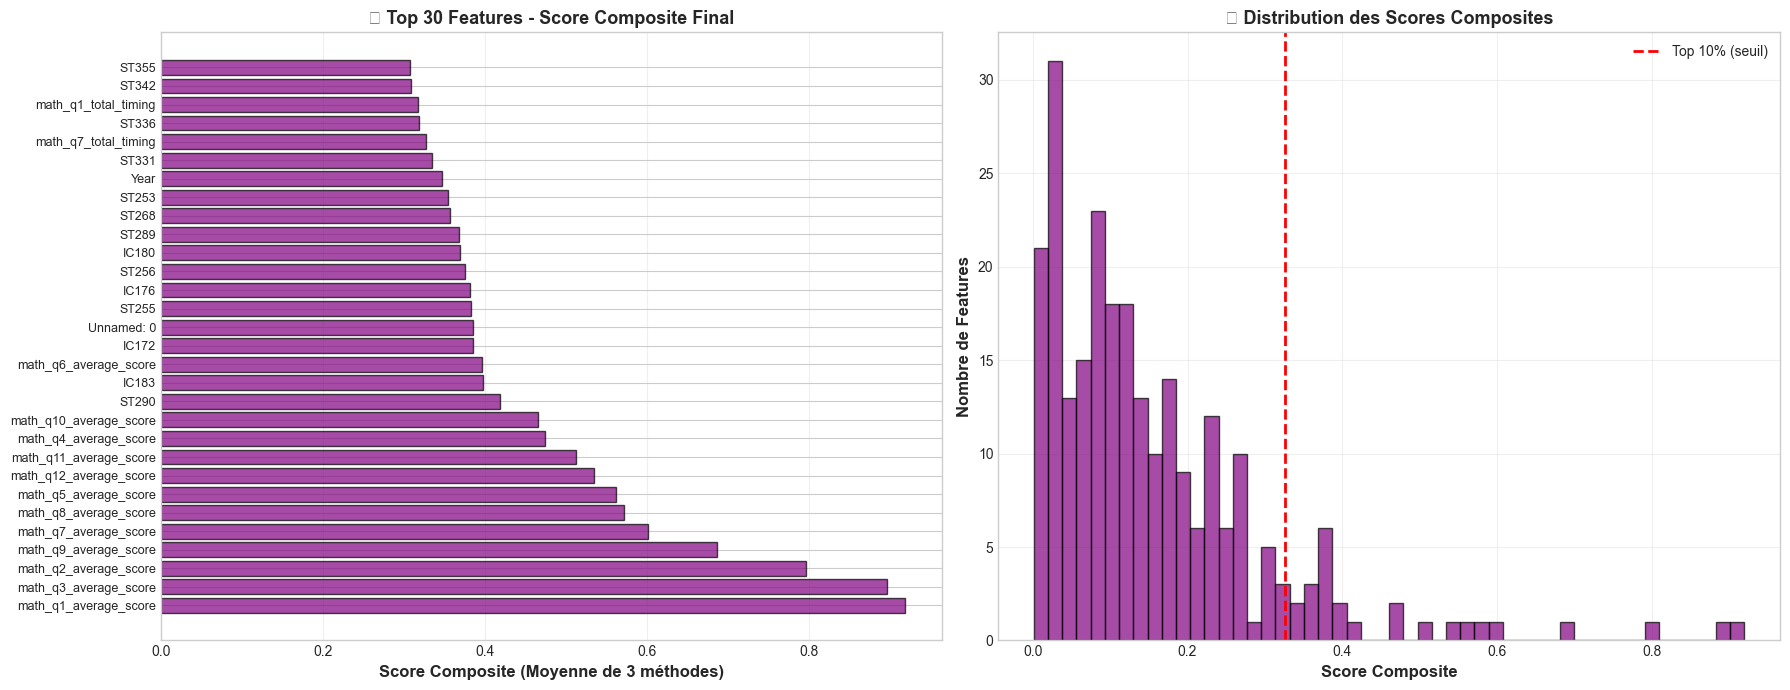


📊 Statistiques des scores composites:
  • Score maximum: 0.9192
  • Score moyen: 0.1566
  • Seuil Top 10%: 0.3256
  • Nombre de features dans le Top 10%: 26


In [17]:
# Visualisation du score composite
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 30 par score composite
top_30_final = final_scores.head(30)

axes[0].barh(range(len(top_30_final)), top_30_final['Composite_Score'], 
             color='purple', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_30_final)))
axes[0].set_yticklabels(top_30_final['Feature'], fontsize=9)
axes[0].set_xlabel('Score Composite (Moyenne de 3 méthodes)', fontsize=12, fontweight='bold')
axes[0].set_title('🏆 Top 30 Features - Score Composite Final', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Distribution des scores composites
axes[1].hist(final_scores['Composite_Score'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1].axvline(x=final_scores['Composite_Score'].quantile(0.9), color='red', linestyle='--', 
                linewidth=2, label='Top 10% (seuil)')
axes[1].set_xlabel('Score Composite', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre de Features', fontsize=12, fontweight='bold')
axes[1].set_title('📊 Distribution des Scores Composites', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques
threshold_90 = final_scores['Composite_Score'].quantile(0.9)
n_features_90 = (final_scores['Composite_Score'] >= threshold_90).sum()

print(f"\n📊 Statistiques des scores composites:")
print(f"  • Score maximum: {final_scores['Composite_Score'].max():.4f}")
print(f"  • Score moyen: {final_scores['Composite_Score'].mean():.4f}")
print(f"  • Seuil Top 10%: {threshold_90:.4f}")
print(f"  • Nombre de features dans le Top 10%: {n_features_90}")

## 🔟 Export des Résultats pour le Machine Learning

In [19]:
# Export des résultats
print("💾 Export des résultats...")

# 1. Export du classement complet des features
final_scores.to_csv('feature_selection/feature_selection_results.csv', index=False)
print("✅ feature_selection_results.csv exporté")

# 2. Export des Top 50 features recommandées
top_50_features = final_scores.head(50)['Feature'].tolist()
pd.DataFrame({'Selected_Features': top_50_features}).to_csv('feature_selection/top_50_features.csv', index=False)
print("✅ top_50_features.csv exporté (Top 50 recommandées)")

# 3. Export des features du Top 10%
top_10_pct = final_scores[final_scores['Composite_Score'] >= threshold_90]['Feature'].tolist()
pd.DataFrame({'Top_10_Percent_Features': top_10_pct}).to_csv('feature_selection/top_10_percent_features.csv', index=False)
print(f"✅ top_10_percent_features.csv exporté ({len(top_10_pct)} features)")

# 4. Créer un rapport synthétique
report = {
    'Métrique': [
        'Total Features Analysées',
        'Features avec |r| > 0.3',
        'Features Top 10% (Recommandées)',
        'Features Top 50 (Très Recommandées)',
        'Features communes aux 3 méthodes',
        'Corrélation max avec Math Score',
        'RF Importance max',
        'Mutual Info max'
    ],
    'Valeur': [
        len(final_scores),
        (corr_df['Abs_Correlation'] > 0.3).sum(),
        len(top_10_pct),
        50,
        len(common_all_3),
        f"{corr_df['Abs_Correlation'].max():.4f}",
        f"{feature_importance['Importance'].max():.4f}",
        f"{mi_scores['MI_Score'].max():.4f}"
    ]
}

report_df = pd.DataFrame(report)
report_df.to_csv('feature_selection/feature_selection_summary.csv', index=False)
print("✅ feature_selection_summary.csv exporté")

print("\n📊 Rapport synthétique:")
display(report_df)

print("\n" + "="*80)
print("✅ ANALYSE TERMINÉE AVEC SUCCÈS!")
print("="*80)
print("\n📁 Fichiers générés:")
print("  1. feature_selection_results.csv - Classement complet avec tous les scores")
print("  2. top_50_features.csv - Top 50 features recommandées pour le ML")
print("  3. top_10_percent_features.csv - Features du Top 10% (les meilleures)")
print("  4. feature_selection_summary.csv - Résumé statistique")
print("\n🎯 Prêt pour l'apprentissage automatique!")

💾 Export des résultats...
✅ feature_selection_results.csv exporté
✅ top_50_features.csv exporté (Top 50 recommandées)
✅ top_10_percent_features.csv exporté (26 features)
✅ feature_selection_summary.csv exporté

📊 Rapport synthétique:


,Métrique,Valeur
0,Total Features Analysées,253
1,Features avec |r| > 0.3,13
2,Features Top 10% (Recommandées),26
3,Features Top 50 (Très Recommandées),50
4,Features communes aux 3 méthodes,8
5,Corrélation max avec Math Score,0.4380
6,RF Importance max,0.2105
7,Mutual Info max,0.7636



✅ ANALYSE TERMINÉE AVEC SUCCÈS!

📁 Fichiers générés:
  1. feature_selection_results.csv - Classement complet avec tous les scores
  2. top_50_features.csv - Top 50 features recommandées pour le ML
  3. top_10_percent_features.csv - Features du Top 10% (les meilleures)
  4. feature_selection_summary.csv - Résumé statistique

🎯 Prêt pour l'apprentissage automatique!


---

## 🎓 Conclusions et Recommandations

### 📊 Résumé de l'Analyse

Cette analyse complète a permis d'identifier les **attributs les plus discriminants** pour prédire le score de mathématiques à travers:

1. **3 Méthodes complémentaires**:
   - 📈 Corrélation de Pearson (relations linéaires)
   - 🌲 Random Forest Importance (interactions non-linéaires)
   - 🔍 Mutual Information (dépendances générales)

2. **Score Composite**: Moyenne des 3 méthodes pour un classement robuste

### 🎯 Recommandations pour le Machine Learning

#### Option 1: Top 50 Features (Recommandée)
- Bon équilibre entre performance et complexité
- Couvre la majorité de l'information prédictive
- Temps d'entraînement raisonnable

#### Option 2: Top 10% Features (Performance maximale)
- Pour maximiser la précision
- Inclut toutes les features importantes
- Plus long à entraîner

#### Option 3: Features communes aux 3 méthodes (Conservative)
- Features les plus robustes et consensuelles
- Réduit le risque d'overfitting
- Modèle plus simple et interprétable

### 🚀 Prochaines Étapes

1. **Preprocessing**:
   - Imputation des valeurs manquantes (médiane/mode)
   - Standardisation (StandardScaler)
   - Encodage des variables catégorielles si présentes

2. **Modélisation**:
   - XGBoost / Random Forest (meilleurs pour PISA)
   - Cross-validation 5-fold
   - Hyperparameter tuning

3. **Évaluation**:
   - RMSE, R², MAE
   - Analyse des résidus
   - SHAP pour l'explicabilité

---

**Équipe HI!CKATHON 2025** - HEC Paris & Institut Polytechnique de Paris